### Exploratory Data Analysis
In this jupyter notebook, we will practice data processing using a real-world dataset of house sale records. The notebook is divided into six parts. For each part, we provide example analysis to guide you. **Your task** is to conduct your own analysis by following the logic shown in the examples.

There are a total of 4 tasks: 3 required and 1 optional. **Note**: when completing the tasks, please provide **not only** the code, but also include necessary comments and discussions, as demonstrated in the examples.

- **Part-1: Data overview**
    > check the #samples, #attributes <br>
    > attribute types <br>
    
- **Part-2: Data cleaning**
    > missing value and outlier detection <br>
    > organize attributes into appripriate data types (e.g., numerical, categorical, datatime, text, image, ...) <br>
    
    
- **Part-3: Categorical data processing**
> missing value / outlier identification and processing <br>
> one-hot/ordinal encoding <br>

- **Part-4: Numerical data processing**
> missing value / outlier identification and processing <br>
> scale data: normalization/standardization <br>

- **Part-5: Text data processing**
> missing value identification and processing <br>
> tokenization <br>
> vectorization <br>
> frequent feature analysis <br>
> non-sense feature analysis <br>


- **Part-6: Additional exploration**
    > DataTime processing <br>
    > creating new features from existing features <br>
    > feature colinearty check <br>
    

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


### Data overview

In [160]:
# read data from file to a pandas dataframe
data_df = pd.read_feather('./house_sales.ftr')

In [161]:
# check the shape of the data frame: row: #samples (short for number of samples), column: #attributes (short for number of attributes)
data_df.shape

(164944, 1789)

In [162]:
# get an overview of the top-n rows/samples
data_df.head()

,Id,Address,Sold Price,Sold On,Summary,Type,Year built,Heating,Cooling,Parking,...,Well Disclosure,remodeled,DOH2,SerialX,Full Baths,Tax Legal Lot Number,Tax Legal Block Number,Tax Legal Tract Number,Building Name,Zip
0,2080183300,"11205 Monterey,","$2,000,000",01/31/20,"11205 Monterey, San Martin, CA 95046 is a sing...",SingleFamily,No Data,No Data,No Data,0 spaces,...,None,None,None,None,None,None,None,None,None,95046
1,20926300,"5281 Castle Rd,","$2,100,000",02/25/21,Spectacular Mountain and incredible L.A. City ...,SingleFamily,1951,Central,"Central Air, Dual","Driveway, Driveway - Brick",...,None,None,None,None,None,None,None,None,None,91011
2,19595300,"3581 Butcher Dr,","$1,125,000",11/06/19,Eichler Style home! with Santa Clara High! in ...,SingleFamily,1954,Central Forced Air - Gas,Central AC,"Garage, Garage - Attached, Covered",...,None,None,None,None,None,None,None,None,None,95051
3,300472200,"2021 N Milpitas Blvd,","$36,250,000",10/02/20,"2021 N Milpitas Blvd, Milpitas, CA 95035 is a ...",Apartment,1989,Other,No Data,"Mixed, Covered",...,None,None,None,None,None,None,None,None,None,95035
4,2074492000,"LOT 4 Tool Box Spring Rd,","$140,000",10/19/20,Beautiful level lot dotted with pine trees ro...,VacantLand,No Data,No Data,No Data,0 spaces,...,None,None,None,None,None,None,None,None,None,92561


### Data cleaning

#### check missing values

In [163]:
null_sum = data_df.isnull().sum()
null_sum

Id                             0
Address                        0
Sold Price                    85
Sold On                        0
Summary                     3117
                           ...  
Tax Legal Lot Number      164943
Tax Legal Block Number    164943
Tax Legal Tract Number    164943
Building Name             164943
Zip                            0
Length: 1789, dtype: int64

In [164]:
# Drop columns that have at least 30% missing values
data_df.drop(columns=data_df.columns[null_sum > len(data_df) * 0.3], inplace=True)

In [165]:
# check the remaining columns
data_df.shape, data_df.columns

((164944, 32),
 Index(['Id', 'Address', 'Sold Price', 'Sold On', 'Summary', 'Type',
        'Year built', 'Heating', 'Cooling', 'Parking', 'Bedrooms', 'Bathrooms',
        'Total interior livable area', 'Total spaces', 'Garage spaces',
        'Home type', 'Region', 'Elementary School', 'Elementary School Score',
        'Elementary School Distance', 'High School', 'High School Score',
        'High School Distance', 'Heating features', 'Parking features',
        'Lot size', 'Parcel number', 'Tax assessed value', 'Annual tax amount',
        'Listed On', 'Listed Price', 'Zip'],
       dtype='object'))

In [166]:
# check the data types: columns with mixed types are stored as "object"
data_df.dtypes

Id                             object
Address                        object
Sold Price                     object
Sold On                        object
Summary                        object
Type                           object
Year built                     object
Heating                        object
Cooling                        object
Parking                        object
Bedrooms                       object
Bathrooms                      object
Total interior livable area    object
Total spaces                   object
Garage spaces                  object
Home type                      object
Region                         object
Elementary School              object
Elementary School Score        object
Elementary School Distance     object
High School                    object
High School Score              object
High School Distance           object
Heating features               object
Parking features               object
Lot size                       object
Parcel numbe

#### organize columns into different data types
The $.dtype$ attribute shows that the current data type for each column is $"object"$, this is either because the column contains missing values or because it contains values of different types.   

We will organize the columns into the following data types (based on the values):
- Categorical:
    > Id, Type, Home type, Region, Elementary School, High School, Parcel number, Zip <br>
- Numerical:
    > Sold Price, Bedrooms, Bathrooms, Total interior livable area, Total spaces, Garage spaces, Elementary School Score, Elementary School Distance, High School Score, High School Distance, Lot size, Tax assessed value, Annual tax amount, Listed Price <br>
- DateTime:
    > Sold On, Year built, Listed On <br>
- Text/String:
    > Address, Summary, Heating, Cooling, Parking, Heating features, Parking features <br>

In the following part, we will:
- convert the original data into the organized data type
- process data of different types

### Categorical data processing

In [167]:
# Convert the following columns to categorical data types
cat_col = ['Id', 'Type', 'Home type', 'Region', 'Elementary School', 'High School', 'Parcel number', 'Zip']
data_df[cat_col] = data_df[cat_col].astype('category')
data_df[cat_col]

,Id,Type,Home type,Region,Elementary School,High School,Parcel number,Zip
0,2080183300,SingleFamily,SingleFamily,San Martin,Rucker Elementary School,Christopher High School,NaN,95046
1,20926300,SingleFamily,SingleFamily,La Canada Flintridge,Mountain Avenue Elementary School,Crescenta Valley High School,5870016003,91011
2,19595300,SingleFamily,SingleFamily,Santa Clara,Pomeroy Elementary School,Santa Clara High School,29022100,95051
3,300472200,Apartment,Apartment,Milpitas,Joseph Weller Elementary School,Milpitas High School,02201015,95035
4,2074492000,VacantLand,NaN,Mountain Center,Mcsweeny Elementary School,West Valley High School,NaN,92561
...,...,...,...,...,...,...,...,...
164939,72555199,Condo,Condo,Richmond,Washington Elementary School,Kennedy High School,5607700878,94804
164940,94643599,Condo,Condo,Los Angeles,Charles H. Kim Elementary School,NaN,5503030207,90010
164941,300479799,Condo,Condo,Mountain View,Edith Landels Elementary School,Mountain View High School,16088037,94043
164942,15504399,SingleFamily,SingleFamily,Pacifica,Cabrillo Elementary School,Jefferson High School,022402090,94044


In [168]:
# the following columns now all have the categorical data types
data_df[cat_col].dtypes

Id                   category
Type                 category
Home type            category
Region               category
Elementary School    category
High School          category
Parcel number        category
Zip                  category
dtype: object

**Outlier detection for each categorical feature**
- Here we take the "Type" column as an example to show the logics

In [169]:
# count the #samples fall into each category
data_df['Type'].value_counts()

Type
SingleFamily                                    102040
Condo                                            27443
MultiFamily                                       7346
Townhouse                                         7108
VacantLand                                        6199
                                                 ...  
Top Floor, Flat, Full, Unit Above, Penthouse         1
Top Floor, Flat, Full                                1
Top Floor, Flat, 2 Level                             1
Top Floor, End Unit, Unit Above                      1
Top Floor, End Unit, Full                            1
Name: count, Length: 317, dtype: int64

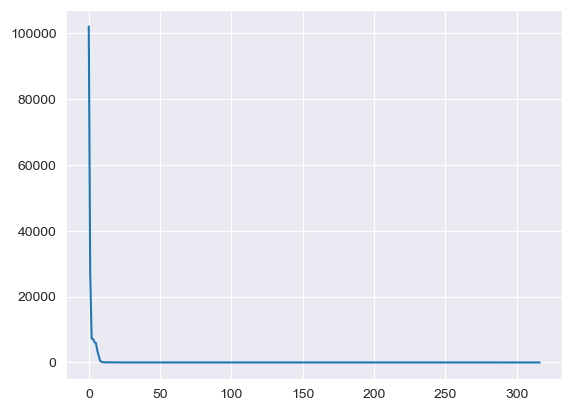

In [170]:
# an alternative method to visualize #samples in each category
plt.plot(data_df['Type'].value_counts().values)

In [171]:
# a closer look at the #samples in each category
data_df['Type'].value_counts().values

array([102040,  27443,   7346,   7108,   6199,   5849,   3605,   1922,
          463,    176,     76,     56,     51,     48,     42,     27,
           21,     19,     19,     19,     18,     15,     14,     14,
           13,     13,     13,     12,     12,     12,     11,     11,
           10,     10,     10,      9,      9,      8,      8,      7,
            7,      7,      7,      7,      7,      6,      6,      6,
            6,      6,      6,      6,      6,      5,      5,      5,
            5,      5,      5,      5,      5,      5,      5,      4,
            4,      4,      4,      4,      4,      4,      4,      4,
            4,      4,      3,      3,      3,      3,      3,      3,
            3,      3,      3,      3,      3,      3,      3,      3,
            3,      3,      3,      3,      3,      2,      2,      2,
            2,      2,      2,      2,      2,      2,      2,      2,
            2,      2,      2,      2,      2,      2,      2,      2,
      

According to the above observation, we take categories that only have a small #samples as outlier/minority categories. To **deal with outliers**:
- we can directly **remove** the outlier categories
- or we can **merge** the minority categories with majority ones (example shown below)

In [172]:
# remove samples whose "Type" belongs to the minority categories
# our criteria here is to remove categories that have less than 10 samples
value_cts = data_df['Type'].value_counts()
cat_to_remove = value_cts[value_cts < 10].keys()
cat_to_remove

CategoricalIndex(['Full', 'RURLRES', 'SINGLE, RURLRES',
                  'Luxury, New Construction, Mid-Rise (4-8)',
                  'Luxury, 2 Level', '1 Story', 'Junior', 'Apartments',
                  '4+ Story', '2 Story, Full',
                  ...
                  'Unit Below, Low-Rise (1-3), Full, Unit Above, Attached',
                  'Unit Below, Low-Rise (1-3), Full',
                  'Unit Below, Flat, Unit Above',
                  'Unit Below, 2 Level, Detached', 'Unit Below',
                  'Top Floor, Flat, Full, Unit Above, Penthouse',
                  'Top Floor, Flat, Full', 'Top Floor, Flat, 2 Level',
                  'Top Floor, End Unit, Unit Above',
                  'Top Floor, End Unit, Full'],
                 categories=['1 Level', '1 Level, Attached', '1 Level, Flat', '1 Level, Flat, Low-Rise (1-3)', ..., 'Unit Below, Low-Rise (1-3), Unit Above', 'Unknown', 'Vacant Land', 'VacantLand'], ordered=False, dtype='category', name='Type', length=282)

In [173]:
print("Data size before dropping minority categories:", data_df.shape)
data_df.drop(data_df[data_df['Type'].isin(cat_to_remove)].index, inplace=True)
print("Data size after dropping minority categories:", data_df.shape)

Data size before dropping minority categories: (164944, 32)
Data size after dropping minority categories: (164401, 32)


In [174]:
# double check the remaining categories
data_df['Type'].astype('string').value_counts()

# question: check what happens if not using astype('string') in the above expression?

Type
SingleFamily            102040
Condo                    27443
MultiFamily               7346
Townhouse                 7108
VacantLand                6199
Unknown                   5849
MobileManufactured        3605
Apartment                 1922
Single Family              463
Cooperative                176
Residential Lot             76
Single Family Lot           56
MFD-F                       51
Acreage                     48
2 Story                     42
3 Story                     27
Hi-Rise (9+), Luxury        21
RESIDENTIAL                 19
Condominium                 19
Duplex                      19
Mid-Rise (4-8)              18
31                          15
Hi-Rise (9+)                14
Vacant Land                 14
Manufactured Home           13
Low-Rise (1-3)              13
Detached                    13
Mobile Home                 12
Detached, 2 Story           12
3 Story, Duplex             12
Top Floor                   11
Residential Sub Lot         11
Lot

In [175]:
# merge minority categories with majority ones (e.g., SINGLE --> SingleFamily, Lots/Land-->VacantLand)
data_df['Type'].replace(['SINGLE', 'Lots/Land'],['SingleFamily', 'VacantLand'], inplace=True)

/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/107799950.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df['Type'].replace(['SINGLE', 'Lots/Land'],['SingleFamily', 'VacantLand'], inplace=True)
/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/107799950.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.ca

In [176]:
# In the resulting categories, 'SINGLE' is merged with "SingleFamily" and 'Lots/Land' is merged with 'VacantLand'
data_df['Type'].value_counts()

Type
SingleFamily                                    102050
Condo                                            27443
MultiFamily                                       7346
Townhouse                                         7108
VacantLand                                        6209
                                                 ...  
Top Floor, Flat, Full, Unit Above, Penthouse         0
Top Floor, Flat, Full                                0
Top Floor, Flat, 2 Level                             0
Top Floor, End Unit, Unit Above                      0
1 Level, Top Floor, Low-Rise (1-3)                   0
Name: count, Length: 315, dtype: int64

#### Task-1: follow the logic of processing the "Type" column to process one of the following columns:
- Region
- Elementary School
- High School

*Notes:*
- You can decide whether to remove outliers or not and what specific threshold to use, based on your observation and common sense.
- You can also decide whether it makes sense to merge multiple categories.
- Please write down your thoughts as comments in the corresponding code cell.

In [177]:
# start your code here
data_df['Region'].value_counts() # counts the number of samples, just like we did with 'Type'

Region
Los Angeles         32800
San Jose            18464
San Francisco       15272
Sunnyvale            2721
San Mateo            2540
                    ...  
Romoland                1
Webster                 1
West Los Angeles        1
West Pt                 1
Arivaca                 1
Name: count, Length: 1433, dtype: int64

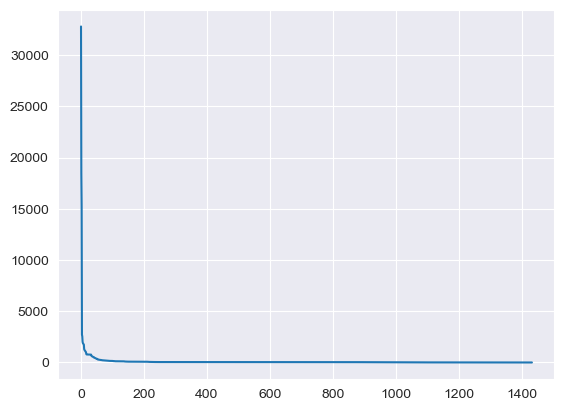

In [178]:
plt.plot(data_df['Region'].value_counts().values) # alternative graph

In [179]:
data_df['Region'].value_counts().values

array([32800, 18464, 15272, ...,     1,     1,     1])

In [180]:
region_counts = data_df['Region'].value_counts() # Find value counts of `Region`
threshold = 100 # thresold of at least 100 samples, so we remove basically 25% of the data, which makes sense to remove outliers!
# Similarly, too few listings in a certain place may make it more difficult to model, so I think it makes sense to drop those with the lowest samples!

region_to_remove = region_counts[region_counts < threshold].keys() # Find regions to remove!
region_to_remove

CategoricalIndex(['Mission Viejo', 'El Monte', 'Sherman Oaks', 'La Puente',
                  'Rural', 'Auburn', 'Royal Oaks', 'Freedom', 'Carson',
                  'Camarillo',
                  ...
                  'Kew', 'Bassett', 'Bayside South', 'Belcamp',
                  'Forks Of Salmon', 'Romoland', 'Webster', 'West Los Angeles',
                  'West Pt', 'Arivaca'],
                 categories=['Acampo', 'Acton', 'Adelanto', 'Adin', ..., 'Yucaipa', 'Yucca Valley', 'Zamora', 'Zenia'], ordered=False, dtype='category', name='Region', length=1294)

In [181]:
print("Data size before dropping minority categories:", data_df.shape) # Size of data before dropping regions that don't meet the threshold

data_df.drop(data_df[data_df['Region'].isin(region_to_remove)].index, inplace=True) 
# Removing such regions with df.drop. Makes more sense, since it would be difficult to rename or rename them to some other region!
 
print("Data size after dropping minority categories:", data_df.shape) # Size of data after...

Data size before dropping minority categories: (164401, 32)
Data size after dropping minority categories: (126846, 32)


In [182]:
data_df['Region'].astype('string').value_counts()

# It wouldn't make sense to merge cities, because they are just different places! Similarly, I feel like it would be very time consuming to replace one-by-one (like sub-region of LA,  etc)

Region
Los Angeles      32800
San Jose         18464
San Francisco    15272
Sunnyvale         2721
San Mateo         2540
                 ...  
Emerald Hills      113
Gardena            112
Thousand Oaks      111
El Cajon           111
Menifee            102
Name: count, Length: 139, dtype: Int64

### Numerical data processing

In [183]:
num_col = ['Sold Price', 'Bathrooms', 'Total interior livable area', 'Total spaces', 'Garage spaces',
           'Elementary School Score', 'Elementary School Distance', 'High School Score', 'High School Distance',
           'Lot size', 'Tax assessed value', 'Annual tax amount', 'Listed Price']

Convert currency from string format (e.g., $1,000,000) to float.

In [184]:
currency = ['Sold Price', 'Listed Price', 'Tax assessed value', 'Annual tax amount']
for c in currency:
    data_df[c] = data_df[c].replace(r'[$,-]', '', regex=True).replace(r'^\s*$', np.nan, regex=True).astype(float)

Convert areas from string format such as 1000 sqft and 1 Acres to float as well.

In [185]:
areas = ['Total interior livable area', 'Lot size']
for c in areas:
    print(c)
    # attribute measured by Acres
    acres = data_df[c].str.contains('Acres') == True

    # e.g., 13,168 sqrt --> 13168
    col = data_df[c].replace(r'\b sqft\b|\b Acres\b|\b,\b','', regex=True).astype(float)

    # Acres --> sqft
    col[acres] *= 43560

    data_df[c] = col

Total interior livable area
Lot size


Now we can **convert the numerical columns to the "float" data type**

In [186]:
data_df[num_col] = data_df[num_col].astype('float')
data_df[num_col]

,Sold Price,Bathrooms,Total interior livable area,Total spaces,Garage spaces,Elementary School Score,Elementary School Distance,High School Score,High School Distance,Lot size,Tax assessed value,Annual tax amount,Listed Price
0,2000000.0,2.0,2000.0,0.0,0.0,6.0,0.7,6.0,1.4,NaN,NaN,NaN,NaN
2,1125000.0,2.0,1517.0,2.0,2.0,4.0,0.6,6.0,0.8,4795.0,1125000.0,13472.0,1299888.0
3,36250000.0,0.0,98052.0,175.0,175.0,7.0,0.4,9.0,0.9,178596.0,14521205.0,175211.0,NaN
6,3200.0,2.0,1572.0,2.0,2.0,6.0,2.4,8.0,4.1,436.0,205077.0,3264.0,794500.0
7,300000.0,1.0,806.0,1.0,1.0,5.0,0.3,9.0,0.9,2953.0,300000.0,3786.0,300000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
164938,1400000.0,3.0,1328.0,2.0,2.0,7.0,0.5,8.0,2.2,1807.0,808223.0,9946.0,1295000.0
164939,563527.0,2.0,959.0,0.0,0.0,3.0,2.5,2.0,1.3,2178.0,486031.0,8243.0,548000.0
164940,2650000.0,3.0,2400.0,2.0,2.0,6.0,0.5,NaN,NaN,53578.8,2757060.0,33279.0,2750000.0
164941,1357000.0,NaN,1355.0,2.0,2.0,7.0,1.2,8.0,2.1,1651.0,1356661.0,16427.0,NaN


In [187]:
# the following columns now all have the numerical data types
data_df[num_col].dtypes

Sold Price                     float64
Bathrooms                      float64
Total interior livable area    float64
Total spaces                   float64
Garage spaces                  float64
Elementary School Score        float64
Elementary School Distance     float64
High School Score              float64
High School Distance           float64
Lot size                       float64
Tax assessed value             float64
Annual tax amount              float64
Listed Price                   float64
dtype: object

Before moving forward, we will first deal with columns that contain **missing values**

In [188]:
# check the missing values of "Sold Price"
data_df['Sold Price'].isna().sum()

np.int64(67)

In [189]:
# we will drop samples where the "Sold Price" is missing
data_df.drop(data_df[data_df['Sold Price'].isna()].index, inplace=True)

In [190]:
# for the other numerical columns, we will fill in missing values with the mean of that column
for col in num_col:
    if col != "Sold Price":
        data_df[col].fillna(value = data_df[col].mean(), inplace=True)

/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/3582017863.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df[col].fillna(value = data_df[col].mean(), inplace=True)


In [191]:
# descriptive statistics for the numerical columns
data_df[num_col].describe()
# If the describe() function is applied on non-numerical columns, the statistics won't make sense.

,Sold Price,Bathrooms,Total interior livable area,Total spaces,Garage spaces,Elementary School Score,Elementary School Distance,High School Score,High School Distance,Lot size,Tax assessed value,Annual tax amount,Listed Price
count,1.267790e+05,126779.000000,1.267790e+05,126779.000000,126779.000000,126779.000000,126779.000000,126779.000000,126779.000000,1.267790e+05,1.267790e+05,1.267790e+05,1.267790e+05
mean,1.353856e+06,2.309026,3.493868e+03,1.681924,1.620306,5.778475,0.745080,6.112152,1.658362,1.027805e+06,1.026254e+06,1.299527e+04,1.340653e+06
std,3.714712e+06,1.477910,4.954958e+05,31.943783,31.937365,2.005182,0.945314,1.937768,1.411691,1.397854e+08,3.310808e+06,4.062091e+04,2.790519e+06
min,1.000000e+00,0.000000,1.000000e+00,-26.000000,-26.000000,1.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,5.500000e+05,2.000000,1.200000e+03,0.000000,0.000000,4.000000,0.300000,5.000000,0.800000,5.000000e+03,4.023105e+05,5.456000e+03,7.200000e+05
50%,9.350000e+05,2.000000,1.632000e+03,1.000000,1.000000,5.778475,0.500000,6.112152,1.400000,6.994000e+03,7.905000e+05,1.038600e+04,1.285000e+06
75%,1.500000e+06,3.000000,2.469000e+03,2.000000,2.000000,7.000000,0.800000,7.000000,1.900000,3.990800e+04,1.087079e+06,1.372350e+04,1.340653e+06
max,8.660000e+08,196.000000,1.764164e+08,9999.000000,9999.000000,10.000000,30.600000,10.000000,34.300000,4.856770e+10,8.256328e+08,9.977342e+06,6.250000e+08


According to the **descriptive statistics**, multiple columns have outliers:
- Bathrooms, Total interior livable area, Total spaces, Garage spaces, Lot size

We will analyze them separately.

#### Analyze "Total interior livable area"

<Axes: xlabel='Total interior livable area'>

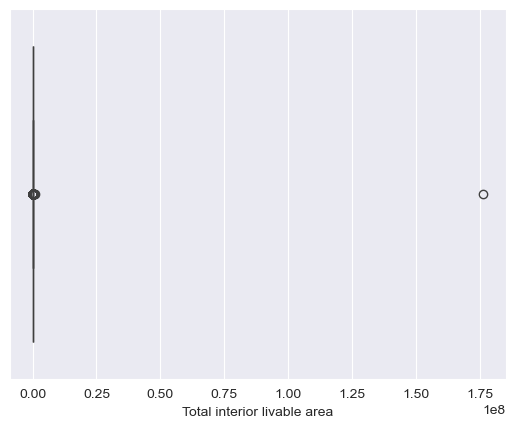

In [192]:
# draw box plot to check outliers
sns.set_style("darkgrid",{'axes.grid' : True})
sns.boxplot(x=data_df['Total interior livable area'], orient='h')

Apply the concept introduced in the slides to calculate the following statistics of the **boxplot**

In [193]:
Q1 = data_df['Total interior livable area'].quantile(0.25)
Q3 = data_df['Total interior livable area'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(1200.0),
 np.float64(2469.0),
 np.float64(-703.5),
 np.float64(4372.5))

In [194]:
data_df.shape

(126779, 32)

In [195]:
# Based on the above calculation, we will remove samples that have "livable area" strictly above 5000 as outliers
data_df.drop(data_df[data_df['Total interior livable area'] > 5000].index, inplace=True)
data_df.shape

(124035, 32)

<Axes: xlabel='Total interior livable area', ylabel='Count'>

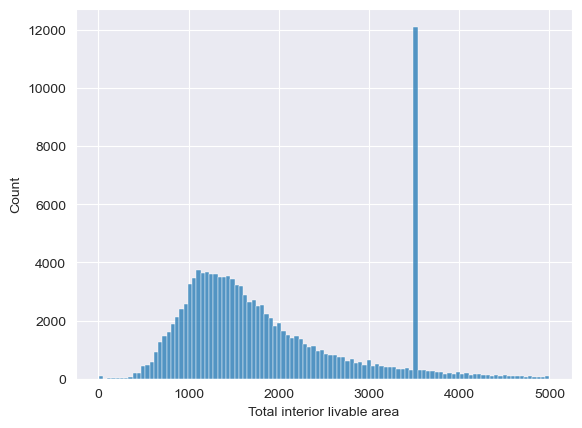

In [196]:
# check the distribution of the "Total interior livable area" after removing outliers
sns.histplot(data_df['Total interior livable area'])

**Normalize** the "Total interior livable area"

In [197]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
data_df['Total interior livable area_normalized'] = scaler.fit_transform(data_df[['Total interior livable area']].values)

<Axes: xlabel='Total interior livable area_normalized', ylabel='Count'>

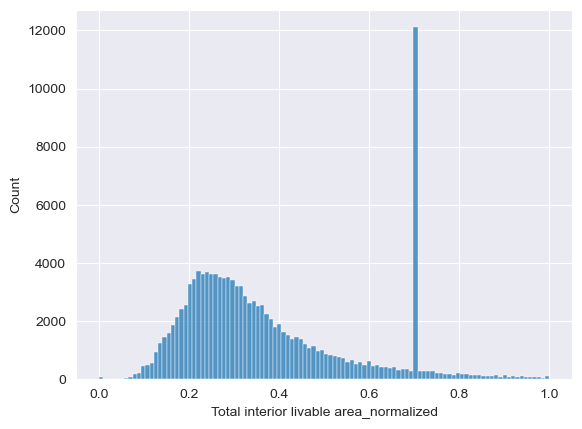

In [198]:
# check the distribution of the "Total interior livable area" (after normalization)
sns.histplot(data_df['Total interior livable area_normalized'])

**Discussion:** compare the data distribution before VS after normalization, we can see that:
- normalization does not change the shape and distribution of the data
- the absolute values of the data are changed, but the relative values do not change
- after normalization, it's more intuitive to understand the relative value of all samples

**Additional analysis**: for attributes with large values (e.g., sold price), we typically apply **log scaling** to process.

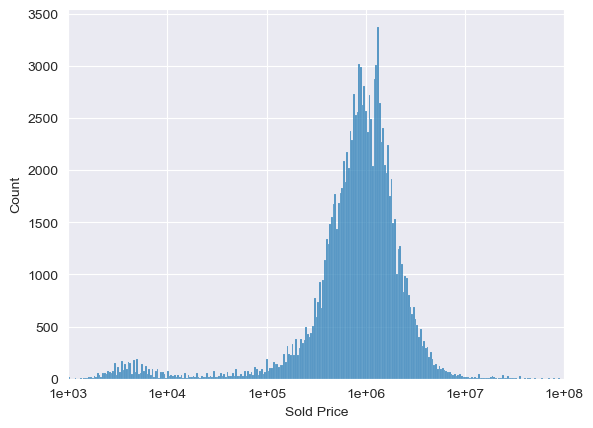

In [199]:
# Check the histogram of the 'Sold Price' after apply log scaling.
ax = sns.histplot(np.log10(data_df['Sold Price']))
ax.set_xlim([3, 8])
ax.set_xticks(range(3, 9))
ax.set_xticklabels(['%.0e'%a for a in 10**ax.get_xticks()]);

# feel free to explore what will happen without log scaling

#### Task-2: follow the numerical data processing logic to process one of the following columns:
- Total spaces
- Garage spaces
- Lot size

*Notes:*
- You can decide the upper/lower threshold of removing outliers, it doesn't have to be the exact upper/lower threshold from the default settings of the boxplot.

<Axes: xlabel='Lot size'>

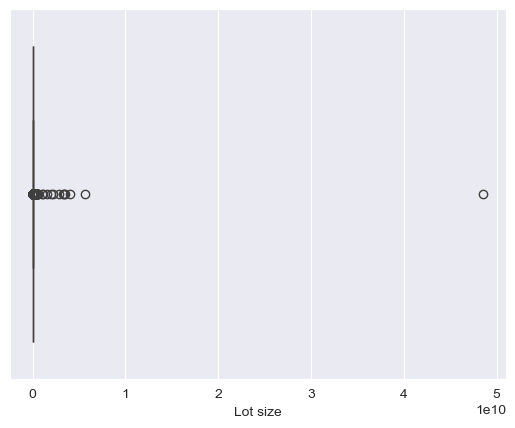

In [200]:
# start your code here
sns.set_style("darkgrid",{'axes.grid' : True})
sns.boxplot(x=data_df['Lot size'], orient='h') # Very skewed data, so it would make sense to nromalize with log scaling!

In [201]:
Q1 = data_df['Lot size'].quantile(0.10) # 10th-percentile 
Q3 = data_df['Lot size'].quantile(0.90) # 90-th percentile

# 10-90th percentile range makes more sense because it's very skewed data, which is still important, so we want to remove extreme outliers!
# People could live in small apartments or houses, but the analysis becomes more difficult if one lives in a farm, for example, so we want to remove huge outliers, especially those right on top of the lot size!

IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(2080.800000000003),
 np.float64(1027805.48131699),
 np.float64(-1536506.2219754849),
 np.float64(2566392.503292475))

In [202]:
data_df.drop(data_df[data_df['Lot size'] > upper_thresh].index, inplace=True) # Remove only those with lot sizes above upper_thresh

# This is because, if one lives, for instance, in a farm, it can get a lot more difficult to price such property! So, we want to reduce outliers.

<Axes: xlabel='Lot size', ylabel='Count'>

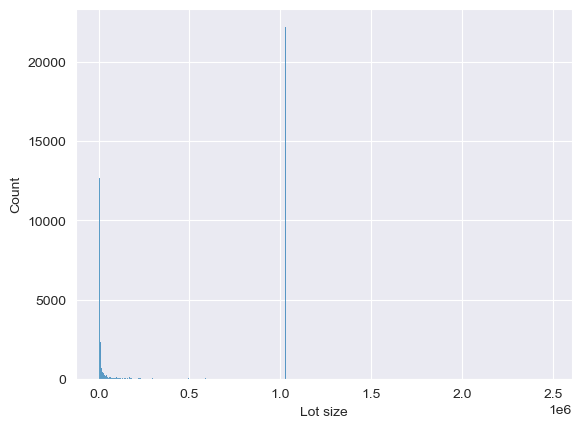

In [203]:
sns.histplot(data_df['Lot size']) 
# some hihgly skewed results, so log makes more sense than min-max scaler, since we want a different distribution

In [204]:
data_df['Lot size'] = np.log10(np.maximum(data_df['Lot size'], 1e-10)) # send zeros to very small number, so we don't trigger an error!

<Axes: xlabel='Lot size', ylabel='Count'>

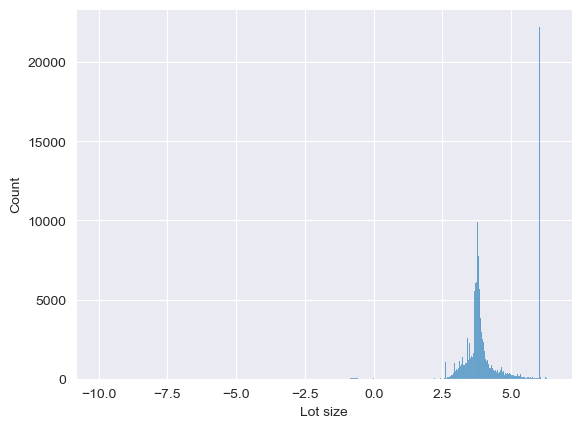

In [205]:
sns.histplot(data_df['Lot size'])  #new distribution with log, a lot easier to see!

### Categorical data processing
- encoding (one-hot/ordinal encoder)

In [206]:
from sklearn.preprocessing import OneHotEncoder

In [207]:
# we will use the "Home type" column as an example to show the encoding logics
data_df['Home type'].value_counts()

Home type
SingleFamily          72987
Condo                 25247
Townhouse              6231
MultiFamily            6197
Unknown                4958
MobileManufactured     2039
Apartment              1606
Cooperative             114
Name: count, dtype: int64

In [210]:
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(data_df[['Home type']])

OneHotEncoder(handle_unknown='ignore')

In [211]:
# the learned categories during model fit
ohe.categories_

[array(['Apartment', 'Condo', 'Cooperative', 'MobileManufactured',
        'MultiFamily', 'SingleFamily', 'Townhouse', 'Unknown', nan],
       dtype=object)]

In [212]:
# encode the "Home type" with the learned categories during the fit process
ohe.transform(data_df[['Home type']]).toarray()[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [213]:
# convert the original "Home type" column to the encoded categories
pd.DataFrame(ohe.transform(data_df[['Home type']]).toarray()).rename(columns={i: catg for i, catg in enumerate(ohe.categories_[0])})

,Apartment,Condo,Cooperative,MobileManufactured,MultiFamily,SingleFamily,Townhouse,Unknown,NaN
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
123823,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
123824,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123825,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123826,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Text data processing

In [214]:
import nltk

In [215]:
text_col = ['Address', 'Summary', 'Heating', 'Cooling', 'Parking', 'Heating features', 'Parking features']

In [216]:
data_df[text_col]

,Address,Summary,Heating,Cooling,Parking,Heating features,Parking features
0,"11205 Monterey,","11205 Monterey, San Martin, CA 95046 is a sing...",No Data,No Data,0 spaces,None,None
2,"3581 Butcher Dr,",Eichler Style home! with Santa Clara High! in ...,Central Forced Air - Gas,Central AC,"Garage, Garage - Attached, Covered","Forced air, Gas","Garage, Garage - Attached, Covered"
6,"7517 Deveron Ct,",This lovely rental is located in the prestigio...,"Forced air, Gas",Central,"Garage, Garage - Attached, Covered","Forced air, Gas","Garage, Garage - Attached, Covered"
7,"3025 E 8th St,","3025 E 8th St, Los Angeles, CA 90023 is a sing...",Wall,Wall/Window Unit(s),"Garage, Covered",Wall,"Garage, Covered"
9,"229 Del Monte Ave,",None,None,None,None,None,None
...,...,...,...,...,...,...,...
164938,"167 Easy St,",Beautifully Upgraded end unit Townhome featuri...,Central Forced Air,None,"Garage, Garage - Attached, Covered",Forced air,"Garage, Garage - Attached, Covered"
164939,"88 Lakeshore Ct,",STUNNING LAKE VIEW AND BAY VIEW! Exquisite Res...,"Baseboard, Electric",None,"Carport, Covered, Guest","Baseboard, Electric","Carport, Covered, Guest"
164940,"3785 Wilshire Blvd PENTHOUSE 3,",Arguably the best unit at Solair. This top flo...,Central,Central,Covered,Other,Covered
164941,"312 Circuit Way,","312 Circuit Way, Mountain View, CA 94043 is a ...",Other,No Data,"Garage, Garage - Attached, Covered",Other,"Garage, Garage - Attached, Covered"


#### Text analysis for the "Summary" column

**tokenization**: the process of breaking down text into the smallest unit in a sentence (e.g., tokens can be words, numbers, punctuation marks)

In [223]:
from nltk import sent_tokenize
from nltk import word_tokenize
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/joaohenriqueguimaraesmartins/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [224]:
# the "Summary" column of the first sample
text = data_df.iloc[0]['Summary']
text

'11205 Monterey, San Martin, CA 95046 is a single family home that contains 2,000 sq ft. It contains 2 bedrooms and 2 bathrooms. This home last sold for $2,000,000 in January 2020. \n \nThe Zestimate for this house is $2,153,229.'

In [225]:
nltk.sent_tokenize(text)

['11205 Monterey, San Martin, CA 95046 is a single family home that contains 2,000 sq ft.',
 'It contains 2 bedrooms and 2 bathrooms.',
 'This home last sold for $2,000,000 in January 2020.',
 'The Zestimate for this house is $2,153,229.']

In [226]:
print(nltk.word_tokenize(text))

['11205', 'Monterey', ',', 'San', 'Martin', ',', 'CA', '95046', 'is', 'a', 'single', 'family', 'home', 'that', 'contains', '2,000', 'sq', 'ft', '.', 'It', 'contains', '2', 'bedrooms', 'and', '2', 'bathrooms', '.', 'This', 'home', 'last', 'sold', 'for', '$', '2,000,000', 'in', 'January', '2020', '.', 'The', 'Zestimate', 'for', 'this', 'house', 'is', '$', '2,153,229', '.']


#### Bag-of-Words vector representation for text data

In [227]:
from sklearn.feature_extraction.text import CountVectorizer

Fill-in **missing values** with empty string

In [228]:
data_df['Summary'].fillna(value='', inplace=True)

/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/3317057329.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df['Summary'].fillna(value='', inplace=True)


Take the "Summary" column from top-100 samples to form a sample corpus, do tokenization and lemmatization

In [229]:
import nltk
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [230]:
corpus = data_df.iloc[:100]['Summary']
corpus_lem = []
for text in corpus:
    word_list = nltk.word_tokenize(text)
    word_lem = [lemmatizer.lemmatize(tok) for tok in word_list]
    corpus_lem.append(' '.join(word_lem))

**Vectorize** the lemmatized corpus with multiple conditions set by the parameters. **Be careful about the parameter settings.**

In [231]:
vectorizer = CountVectorizer(min_df=5, max_df=0.8,ngram_range=(1,1),binary=False,stop_words='english')
X = vectorizer.fit_transform(corpus_lem)

In [232]:
# check the feature matrix of the vectorized corpus
X.shape

(100, 270)

In [233]:
# check the extracted features during the vectorization
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['000', '2018', '2019', '2020', '280', '300', '400', '500',
       'access', 'added', 'additional', 'adu', 'air', 'amazing',
       'amenity', 'ample', 'angeles', 'apple', 'appliance', 'area',
       'attached', 'ave', 'away', 'backyard', 'bar', 'bath', 'bathroom',
       'bay', 'beach', 'beautiful', 'beautifully', 'bedroom', 'bedrooms',
       'big', 'block', 'boast', 'brand', 'breakfast', 'bright',
       'building', 'built', 'buyer', 'ca', 'cabinet', 'cabinetry', 'car',
       'carpet', 'ceiling', 'center', 'central', 'charming', 'check',
       'city', 'close', 'closet', 'club', 'come', 'community', 'commute',
       'complex', 'condo', 'condominium', 'contains', 'conveniently',
       'counter', 'countertop', 'cozy', 'credit', 'cul', 'custom', 'deck',
       'den', 'designed', 'desirable', 'detached', 'dining', 'distance',
       'district', 'door', 'downstairs', 'downtown', 'driveway', 'dryer',
       'dual', 'easy', 'eat', 'elementary', 'enjoy', 'entertaining',
       'ent

Find out the **top-10 most frequent features**

In [234]:
def get_topn_features(X, feature_names, topn=10):
    """
    Inputs:
        X: feature matrix
        feature_names: extracted features during vectorization
        topn: the number of most frequent features to return
    Outputs:
        topn most frequent features and their frequency
    """
    feature_ct = np.asarray(np.sum(X, axis=0)).reshape(-1)

    feature_freq = []

    for i in np.argsort(feature_ct)[::-1][:topn]:
        feature_freq.append({'feature':feature_names[i], 'frequency':feature_ct[i]})

    return pd.DataFrame(feature_freq)

In [235]:
get_topn_features(X, feature_names, topn=10)

,feature,frequency
0,home,185
1,room,103
2,new,97
3,bedroom,86
4,kitchen,67
5,living,65
6,bathroom,58
7,ha,58
8,floor,51
9,family,49


The top-10 most frequent words show that most house "Summary" describe the house conditions from the aspect of new, bedroom, bathroom, living, kitchen, floor. **However**, it is unclear why "ha" appears to be a frequent word. We need to find out documents that contain "ha" and explore the specific reason.

In [236]:
# find the index of "ha" from the feature list
np.where(feature_names == 'ha')

(array([115]),)

In [237]:
# find "ha" from the lemmatized corpus
np.array(corpus_lem)[np.where(X[:, 109].toarray() > 0)[0]][:2] # only select two samples for visualization purpose

array(['This fabulous 2019 Brand Newly Built Traditional Cape Cod home captivates with spatial grandeur and top-tier finish for prime comfort . The impressive foyer open to a living room adjoining a study room . The open floor plan ha an expansive living , dining and family room with a fireplace . The custom designed gourmet kitchen includes gorgeous cabinet with high-end stainless steel Wolf and Sub Zero appliance , wine cooler , and a vibrant white quartz countertop . This smart house ha speaker all throughout the inside and outside of the house that you can control with the touch of your phone making it perfect for entertaining . Warm European Oak floor , high ceiling , all highlighted with recess led lighting and beautiful picture window throughout the house give a bright , cheerful and plenty of natural lighthouse . The Ultra Private Master Suite ha a customized walk-in closet that lead to a luxurious spa styled bath highlighted by it dual sink vanity , a free-standing tub , and a

In [238]:
# find "ha" from the raw corpus before tokenization and lemmatization
corpus.values[np.where(X[:, 109].toarray() > 0)[0]][:2] # only select two samples for visualization purpose

array(['This fabulous 2019 Brand Newly Built Traditional Cape Cod home captivates with spatial grandeur and top-tier finishes for prime comfort. The impressive foyer opens to a living room adjoining a study room. The open floor plan has an expansive living, dining and family room with a fireplace. The custom designed gourmet kitchen includes gorgeous cabinets with high-end stainless steel Wolf and Sub Zero appliances, wine cooler, and a vibrant white quartz countertop. This smart house has speakers all throughout the inside and outside of the house that you can control with the touch of your phone making it perfect for entertaining. Warm European Oak floors, high ceilings, all highlighted with recess led lighting and beautiful picture windows throughout the house gives a bright, cheerful and plenty of natural lighthouse. The Ultra Private Master Suite has a customized walk-in closet that leads to a luxurious spa styled bath highlighted by its dual sink vanities, a free-standing tub, an

In [239]:
# according to the above observation, it seems like "ha" is the lemma of "has"
lemmatizer.lemmatize('has')

'ha'

**Discussion**:
- Based on the above exploration, we know that "ha" appears to be a frequent word, because it is lemmatized from "has", which is frequently used in the "Summary" description. <br>
- According to our common sense, "ha" doesn't provide deeper understanding of the house's "Summary" information. So we can process it as a stop-word and remove it during the vectorization process.

In [ ]:
# add self-defined stop-words
from sklearn.feature_extraction import text
new_stop_words = text.ENGLISH_STOP_WORDS.union(['ha'])
# start from vectorization to repeat the above process
# In real-world tasks, you might need to repeat the above process multiple times to remove unreasonable features

#### Task-3: process the "Summary" column for all samples
- In the above process, we showed the logics for doing text processing on 100 samples.
- In the next part, please follow the logic to process the "Summary" column for all samples.
- Find out the top-20 most frequent words (you might repeat the process multiple times until the top-20 most frequent words make sense to you).

In [240]:
# start your code here
corpus = data_df['Summary'].fillna('') # --> obtain Summary column for all samples and fill missing values
corpus_lem = []

for text in corpus: # Run for loop to vectorize and lemmetize words!
    word_list = nltk.word_tokenize(text)
    word_lem = [lemmatizer.lemmatize(tok) for tok in word_list]
    corpus_lem.append(' '.join(word_lem))

In [241]:
vectorizer = CountVectorizer(min_df=5, max_df=0.8,ngram_range=(1,1),binary=False,stop_words='english') 
# Remove enlish stop words, ignore words that show up in less than 5 listings or more than 80%, and keep unigrams
X = vectorizer.fit_transform(corpus_lem) # fit data

In [242]:
X.shape #test shape, which makes sense so we're actually computing the entire dataset

(123828, 18983)

In [243]:
feature_names = vectorizer.get_feature_names_out()
feature_names # various different names, which is great!

array(['00', '000', '0000', ..., 'â½', 'â¾', 'ãƒâ'], dtype=object)

In [247]:
get_topn_features(X, feature_names, topn=20) # by doing this, we get the 20 most frequent words!
#zestimate is quite interesting, it's likely because it comes from Zillow
#ha is likely referencing "hectares," which contributes to the hypothesis that there's lots of farm listings!

,feature,frequency
0,home,204725
1,bedroom,117241
2,room,115136
3,kitchen,81439
4,new,74372
5,floor,72519
6,bathroom,71723
7,living,68276
8,large,60555
9,ha,59710


### Additional exploration

#### Date-time representation
- In this part, we will process the columns that are formated as DataTime by generating a corresponding feature list such as: [year, month, day]

In [248]:
data_col = ['Sold On', 'Year built', 'Listed On']

In [249]:
# we will use the "Sold On" column as an example to show the processing logics
data_df.iloc[:10]['Sold On']

0     01/31/20
2     11/06/19
6     08/31/19
7     11/06/19
9     08/31/18
10    01/13/21
11    12/18/20
13    03/18/19
14    09/03/20
15    08/14/20
Name: Sold On, dtype: object

In [250]:
# convert the column to DataTime type
data_df['Sold On'] = pd.to_datetime(data_df['Sold On'], infer_datetime_format=True)

/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/1496694987.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data_df['Sold On'] = pd.to_datetime(data_df['Sold On'], infer_datetime_format=True)
/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/1496694987.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_df['Sold On'] = pd.to_datetime(data_df['Sold On'], infer_datetime_format=True)


In [251]:
# extract year/month/day or other corresponding features
data_df['Sold_Year'] = data_df['Sold On'].apply(lambda time: time.year)
data_df['Sold_Month'] = data_df['Sold On'].apply(lambda time: time.month)
data_df['Sold_Day'] = data_df['Sold On'].apply(lambda time: time.day)

In [252]:
data_df[['Sold On', 'Sold_Year', 'Sold_Month', 'Sold_Day']]

,Sold On,Sold_Year,Sold_Month,Sold_Day
0,2020-01-31,2020,1,31
2,2019-11-06,2019,11,6
6,2019-08-31,2019,8,31
7,2019-11-06,2019,11,6
9,2018-08-31,2018,8,31
...,...,...,...,...
164938,2020-07-06,2020,7,6
164939,2021-02-19,2021,2,19
164940,2018-05-31,2018,5,31
164941,2019-11-04,2019,11,4


#### Create new features and check colinearty

In [253]:
# Houses could have different types, here are the top types:
data_df['Type'].value_counts()[0:10]

Type
SingleFamily          72815
Condo                 25163
Townhouse              6233
MultiFamily            6160
Unknown                4956
VacantLand             2734
MobileManufactured     2036
Apartment              1605
Cooperative             114
Single Family            81
Name: count, dtype: int64

We want to **calculate an additional feature "price per living sqft" from the current features**, an important measurement of final house price. Let's check the differences between different house types.

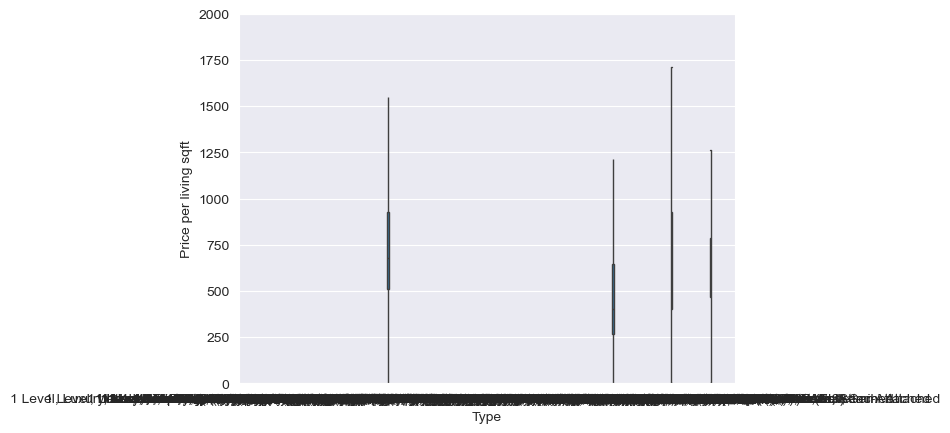

In [254]:
common_types = data_df['Type'].isin(['SingleFamily', 'Condo', 'MultiFamily', 'Townhouse'])
data_df['Price per living sqft'] = data_df['Sold Price'] / data_df['Total interior livable area']
ax = sns.boxplot(x='Type', y='Price per living sqft', data=data_df[common_types], fliersize=0)
ax.set_ylim([0, 2000]);

Sale price per living sqft is often related with house locations. Let's check the price for the top 20 zip codes.

In [255]:
data_df['Zip'].value_counts()[:20]

Zip
95003    794
95131    789
94089    788
94404    786
95118    785
95133    785
94043    784
95124    783
94087    783
95148    783
95136    783
95062    782
95132    782
95123    782
95066    781
95135    781
94403    781
95122    780
95111    778
94002    778
Name: count, dtype: int64

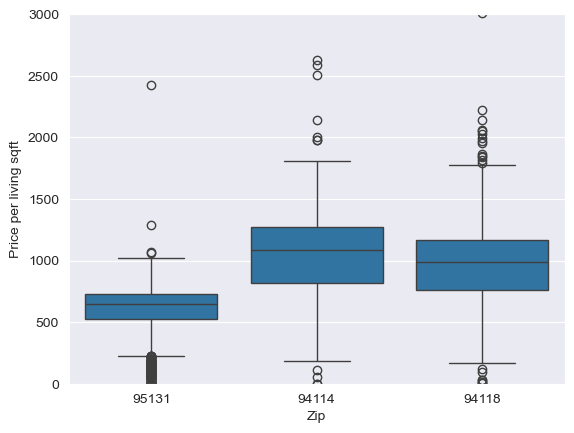

In [256]:
data_df['Zip'] = data_df['Zip'].astype('string')
data_df['Price per living sqft'] = data_df['Sold Price'] / data_df['Total interior livable area']
mask = data_df['Zip'].isin(['95131','94114', '94118'])
ax = sns.boxplot(x='Zip', y='Price per living sqft', data=data_df[mask])
ax.set_ylim([0, 3000]);

/var/folders/rb/2wnkwm5n1kq146j18sbrkzj80000gn/T/ipykernel_13571/1739456248.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


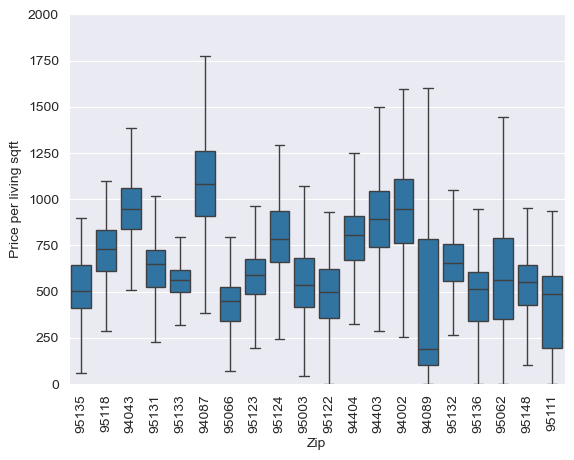

In [257]:
d = data_df[data_df['Zip'].isin(data_df['Zip'].value_counts()[:20].keys())]
ax = sns.boxplot(x='Zip', y='Price per living sqft', data=d, fliersize=0)
ax.set_ylim([0, 2000])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);

In some cases, we also need to check the correlations among multiple columns:
- as a way to measure **colinearty**
- visualize the correlation matrix as a **heatmap**

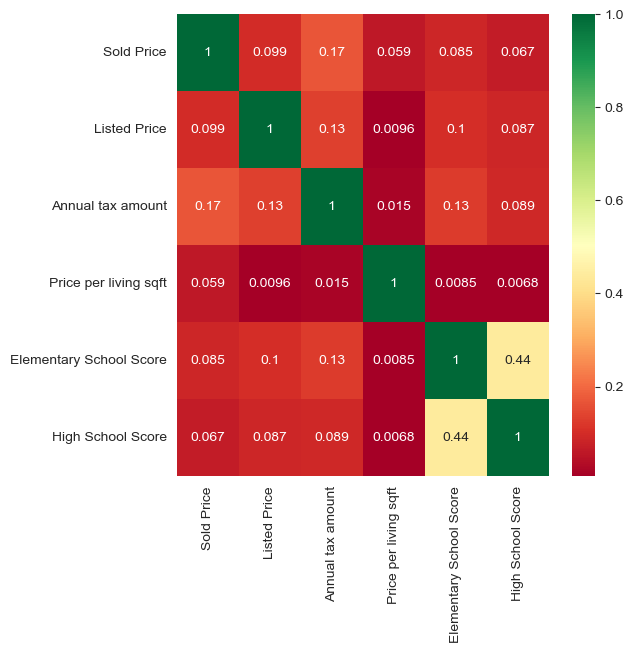

In [260]:
_, ax = plt.subplots(figsize=(6,6))
columns = ['Sold Price', 'Listed Price', 'Annual tax amount', 'Price per living sqft', 'Elementary School Score', 'High School Score']
sns.heatmap(data_df[columns].corr(),annot=True,cmap='RdYlGn', ax=ax);

According to the heat map, we can observe that:
- sold price is not closely correlated with the listed price
- sold price has some correlation with the annual tax amount

**Task-4 (Optional)**: what other conclusions do you have? Could you explain these correlations from social science perspective?


In [261]:
# start your code here


### Summary

In this notebook, we practiced fundamental processing techniques for various types of data, including:

  - Data overview (understanding data types, values, and distributions)
  - Data cleaning (remove missing values, detect and handle outliers)
  - Categorical data processing (one-hot encoding, ordinal encoding)
  - Numerical data processing (normalization, standardization)
  - Text data processing (CountVectorizer)
  - Understanding the interactions between columns (colinearty examination)

This is just a starting point -- feel free to further explore the dataset and uncover deeper insights.